# PROBLEM STATEMENT

In the competitive landscape of e-commerce, companies must offer highly personalized user experiences to stand out among industry leaders like Amazon and Flipkart. Ebuss, a rapidly growing e-commerce platform, aims to enhance its product recommendation engine by incorporating customer sentiments expressed in product reviews. As a Senior Machine Learning Engineer at Ebuss, your objective is to develop an end-to-end sentiment-based product recommendation system that not only predicts user sentiments from reviews but also uses these sentiments to refine and prioritize product recommendations.

This project involves multiple stages: analyzing a large dataset of user reviews, building and evaluating sentiment classification models, designing an effective recommendation system, integrating sentiment insights to improve the quality of recommendations, and deploying a user-facing web application using Flask and Heroku. The final solution should recommend the top 5 most relevant products to users based on both historical ratings and inferred sentiments, thereby improving customer satisfaction and increasing engagement on the Ebuss platform.

# OBJECTIVE

Build a sentiment classification model from product reviews.

Develop a recommendation system based on user-item interactions.

Enhance recommendations using sentiment scores.

Deploy the complete solution using Flask and Heroku.

# 1. Data Analysis

In [1]:
#import libraries

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import LancasterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from tqdm import tqdm
from wordcloud import WordCloud, STOPWORDS
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
import math
from prettytable import PrettyTable

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
#Others
import warnings
warnings.filterwarnings('ignore')

import pickle

%matplotlib inline

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
#load the dataset
df = pd.read_csv("sample30.csv")
df.head()

,id,brand,categories,manufacturer,name,reviews_date,reviews_didPurchase,reviews_doRecommend,reviews_rating,reviews_text,reviews_title,reviews_userCity,reviews_userProvince,reviews_username,user_sentiment
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Mo...",Universal Music Group / Cash Money,Pink Friday: Roman Reloaded Re-Up (w/dvd),2012-11-30T06:21:45.000Z,NaN,NaN,5,i love this album. it's very good. more to the...,Just Awesome,Los Angeles,NaN,joshua,Positive
1,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor. This review was collected as part...,Good,NaN,NaN,dorothy w,Positive
2,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor.,Good,NaN,NaN,dorothy w,Positive
3,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",K-Y,K-Y Love Sensuality Pleasure Gel,2016-01-06T00:00:00.000Z,False,False,1,I read through the reviews on here before look...,Disappointed,NaN,NaN,rebecca,Negative
4,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",K-Y,K-Y Love Sensuality Pleasure Gel,2016-12-21T00:00:00.000Z,False,False,1,My husband bought this gel for us. The gel cau...,Irritation,NaN,NaN,walker557,Negative


In [3]:
#display the shape
df.shape

(30000, 15)

### Observation: 
Identified that, total of 30000 reviews exists with 15 columns

In [4]:
df.describe()

,reviews_rating
count,30000.000000
mean,4.483133
std,0.988441
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [5]:
df.info(verbose=1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    30000 non-null  object
 1   brand                 30000 non-null  object
 2   categories            30000 non-null  object
 3   manufacturer          29859 non-null  object
 4   name                  30000 non-null  object
 5   reviews_date          29954 non-null  object
 6   reviews_didPurchase   15932 non-null  object
 7   reviews_doRecommend   27430 non-null  object
 8   reviews_rating        30000 non-null  int64 
 9   reviews_text          30000 non-null  object
 10  reviews_title         29810 non-null  object
 11  reviews_userCity      1929 non-null   object
 12  reviews_userProvince  170 non-null    object
 13  reviews_username      29937 non-null  object
 14  user_sentiment        29999 non-null  object
dtypes: int64(1), object(14)
memory usage

### Observation: 
Total 15 columns are object based columns

## 1.1 Data Check:

In [7]:
data_duplicates = df.duplicated()
data_duplicates[data_duplicates==True]

Series([], dtype: bool)

### Observations:

There are no duplicate records found and data is in good shape to proceed with further analysis.

## 1.2 Check Imbalance

In [8]:
df["user_sentiment"].value_counts()

user_sentiment
Positive    26632
Negative     3367
Name: count, dtype: int64

### Observation: 
Identified that, imbalance is existed across the sentiments. We have to carefully balance the data and apply ML techniques.

## 1.3 Check MIssing Values

In [9]:
# Checking the percentage of missing values
missingvalues = round(100*(df.isnull().sum()/len(df.index)), 2).sort_values(ascending=False)
missingvalues

missing_value_df = pd.DataFrame({'column_name': missingvalues.index,
                                 'percent_missing': missingvalues.values})
missing_value_df

,column_name,percent_missing
0,reviews_userProvince,99.43
1,reviews_userCity,93.57
2,reviews_didPurchase,46.89
3,reviews_doRecommend,8.57
4,reviews_title,0.63
5,manufacturer,0.47
6,reviews_username,0.21
7,reviews_date,0.15
8,id,0.00
9,brand,0.00


### Observation: 
Identified that, there are missing values in certain columns. Lets remove the columns where the data is missing more than 50 percentage

In [10]:
#drop the columns
df = df.drop(columns=['id','reviews_userProvince','reviews_userCity'],axis=1)
df.head()

,brand,categories,manufacturer,name,reviews_date,reviews_didPurchase,reviews_doRecommend,reviews_rating,reviews_text,reviews_title,reviews_username,user_sentiment
0,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Mo...",Universal Music Group / Cash Money,Pink Friday: Roman Reloaded Re-Up (w/dvd),2012-11-30T06:21:45.000Z,NaN,NaN,5,i love this album. it's very good. more to the...,Just Awesome,joshua,Positive
1,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor. This review was collected as part...,Good,dorothy w,Positive
2,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor.,Good,dorothy w,Positive
3,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",K-Y,K-Y Love Sensuality Pleasure Gel,2016-01-06T00:00:00.000Z,False,False,1,I read through the reviews on here before look...,Disappointed,rebecca,Negative
4,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",K-Y,K-Y Love Sensuality Pleasure Gel,2016-12-21T00:00:00.000Z,False,False,1,My husband bought this gel for us. The gel cau...,Irritation,walker557,Negative


In [11]:
# Checking the percentage of missing values
missingvalues = round(100*(df.isnull().sum()/len(df.index)), 2).sort_values(ascending=False)
missingvalues

missing_value_df = pd.DataFrame({'column_name': missingvalues.index,
                                 'percent_missing': missingvalues.values})
missing_value_df

,column_name,percent_missing
0,reviews_didPurchase,46.89
1,reviews_doRecommend,8.57
2,reviews_title,0.63
3,manufacturer,0.47
4,reviews_username,0.21
5,reviews_date,0.15
6,brand,0.00
7,categories,0.00
8,name,0.00
9,reviews_rating,0.00


### Observation: 
Missing data columns are removed

# 2. EDA Analysis


## 2.1 UniVariate Analysis

In [12]:
#lets define the function to plot the columns in bar graph
def top20(df, column_name):
    top = df[column_name].value_counts().head(20).index
    filtered = df[df[column_name].isin(top)]
    sns.countplot(y=filtered[column_name], order=top)
    plt.show()
   

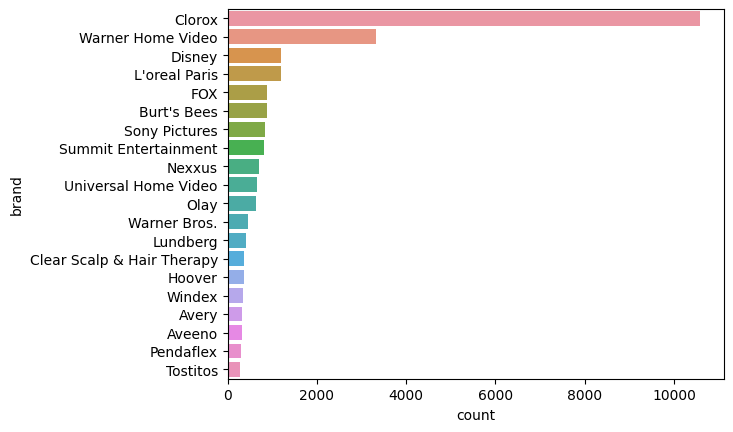

In [13]:
top20(df, 'brand')

### Observation: 
People reviewed more on Clorox brand and following by Warner Home Video

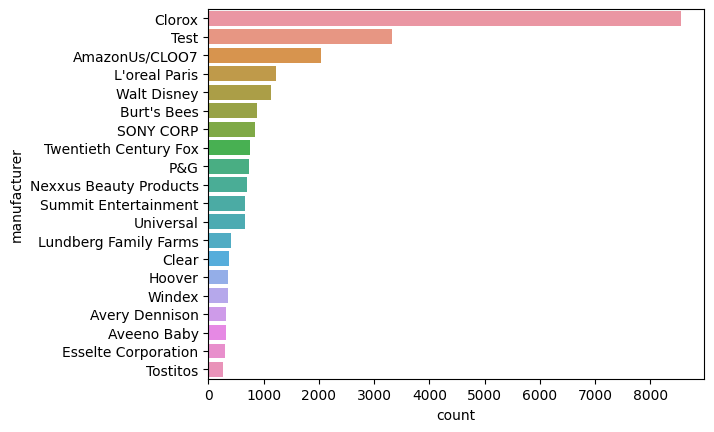

In [13]:
top20(df, 'manufacturer')

### Observation: 
People reviewed more on Clorox Manufacturer and following by Test

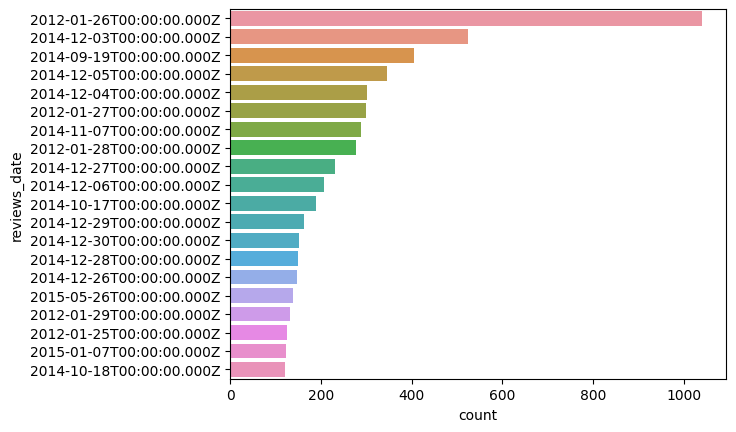

In [14]:
top20(df, 'reviews_date')

### Observation: 
People reviewed more on 26 Jan 2012 and following by on 2014 December

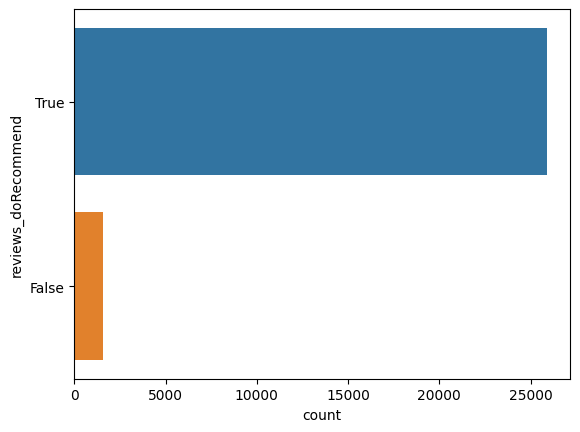

In [16]:
top20(df, 'reviews_doRecommend')

### Observation: 
People bought most of the products based on the reviews of each product

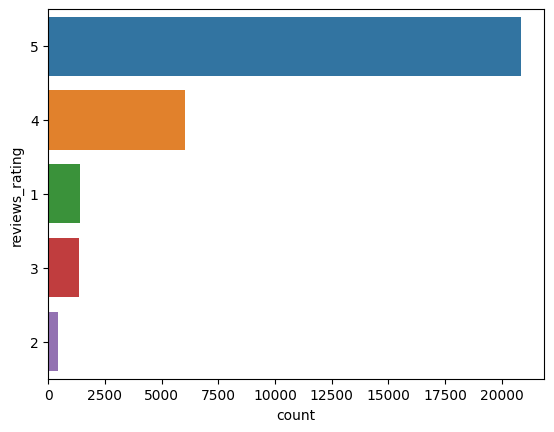

In [17]:
top20(df, 'reviews_rating')

### Observation: 
Most of the ratings given as 5 star ratings compared with other ratings.

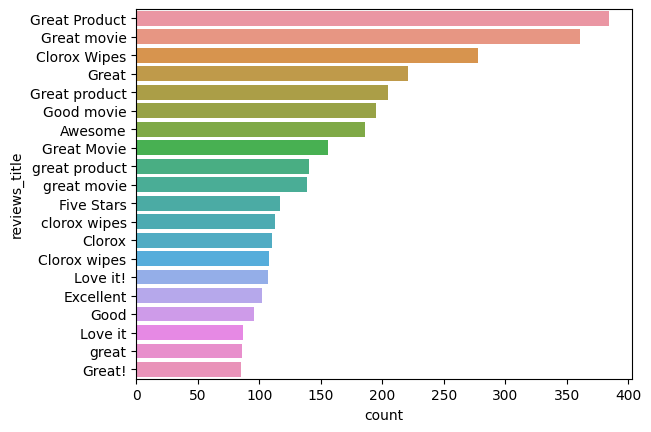

In [18]:
top20(df, 'reviews_title')

### Observation: 
People reviews provided on product based and movie based

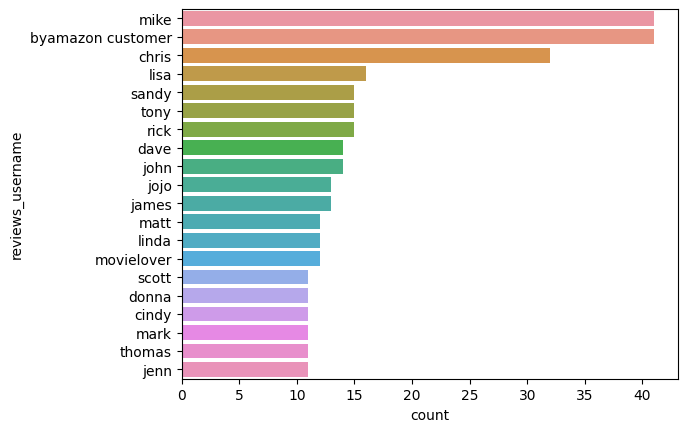

In [19]:
top20(df, 'reviews_username')

### Observation: 
Mike and byamazon customer users are most given reviews when compared with others

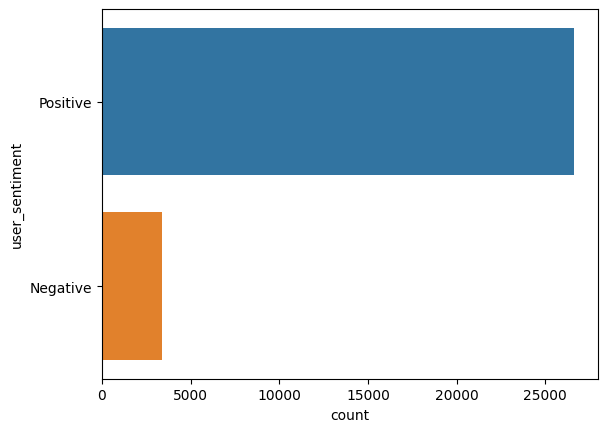

In [20]:
top20(df, 'user_sentiment')

### Observation: 
Sentiment across the reviews are mostly postivie and less negative

In [21]:
df.head()

,brand,categories,manufacturer,name,reviews_date,reviews_didPurchase,reviews_doRecommend,reviews_rating,reviews_text,reviews_title,reviews_username,user_sentiment
0,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Mo...",Universal Music Group / Cash Money,Pink Friday: Roman Reloaded Re-Up (w/dvd),2012-11-30T06:21:45.000Z,NaN,NaN,5,i love this album. it's very good. more to the...,Just Awesome,joshua,Positive
1,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor. This review was collected as part...,Good,dorothy w,Positive
2,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor.,Good,dorothy w,Positive
3,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",K-Y,K-Y Love Sensuality Pleasure Gel,2016-01-06T00:00:00.000Z,False,False,1,I read through the reviews on here before look...,Disappointed,rebecca,Negative
4,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",K-Y,K-Y Love Sensuality Pleasure Gel,2016-12-21T00:00:00.000Z,False,False,1,My husband bought this gel for us. The gel cau...,Irritation,walker557,Negative


In [22]:
#map positive to 1 and negative to 0 in user_sentiment column
df['user_sentiment'] = df['user_sentiment'].map({'Positive': 1, 'Negative': 0}).fillna(0).astype(int)

In [23]:
df.head()

,brand,categories,manufacturer,name,reviews_date,reviews_didPurchase,reviews_doRecommend,reviews_rating,reviews_text,reviews_title,reviews_username,user_sentiment
0,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Mo...",Universal Music Group / Cash Money,Pink Friday: Roman Reloaded Re-Up (w/dvd),2012-11-30T06:21:45.000Z,NaN,NaN,5,i love this album. it's very good. more to the...,Just Awesome,joshua,1
1,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor. This review was collected as part...,Good,dorothy w,1
2,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor.,Good,dorothy w,1
3,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",K-Y,K-Y Love Sensuality Pleasure Gel,2016-01-06T00:00:00.000Z,False,False,1,I read through the reviews on here before look...,Disappointed,rebecca,0
4,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",K-Y,K-Y Love Sensuality Pleasure Gel,2016-12-21T00:00:00.000Z,False,False,1,My husband bought this gel for us. The gel cau...,Irritation,walker557,0


## 2.2 Multivariate Analysis

<Axes: xlabel='reviews_rating', ylabel='user_sentiment'>

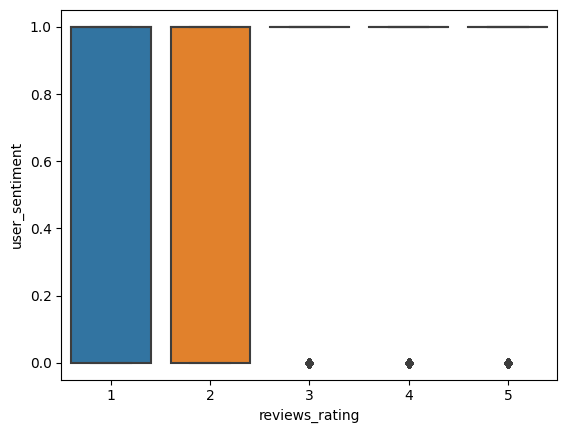

In [24]:
sns.boxplot(x=df['reviews_rating'],y=df['user_sentiment'])

<Axes: xlabel='reviews_didPurchase', ylabel='user_sentiment'>

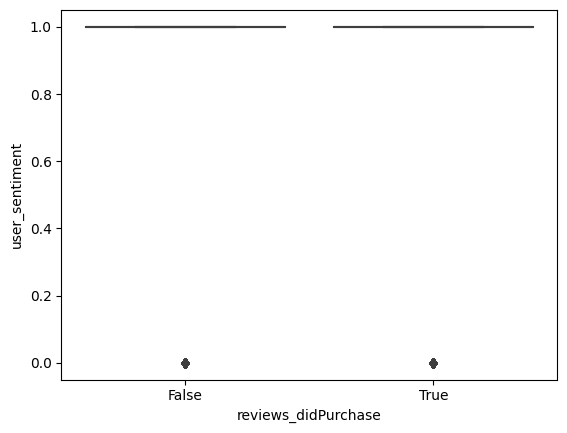

In [25]:
sns.boxplot(x=df['reviews_didPurchase'],y=df['user_sentiment'])

<Axes: xlabel='reviews_doRecommend', ylabel='user_sentiment'>

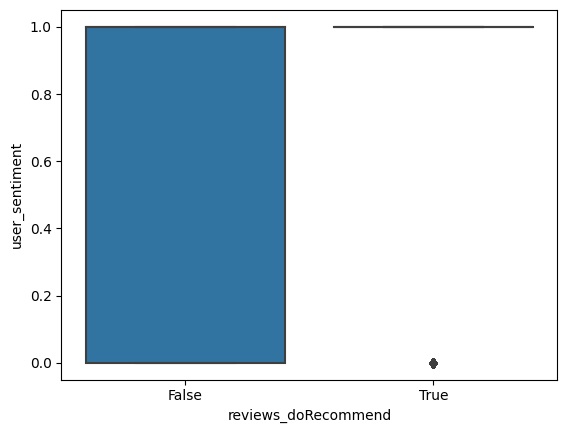

In [26]:
sns.boxplot(x=df['reviews_doRecommend'],y=df['user_sentiment'])

### Observations:

Above boxplots doesn't give any information much

Average Review Lengths by Sentiment:
                reviewwcount  reviewccount
user_sentiment                            
0                  31.370249    165.820071
1                  34.767160    185.236820


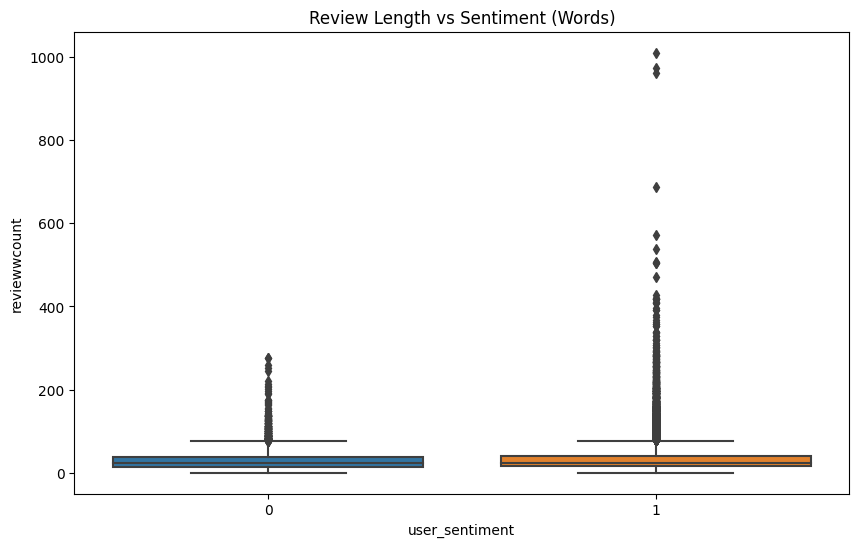

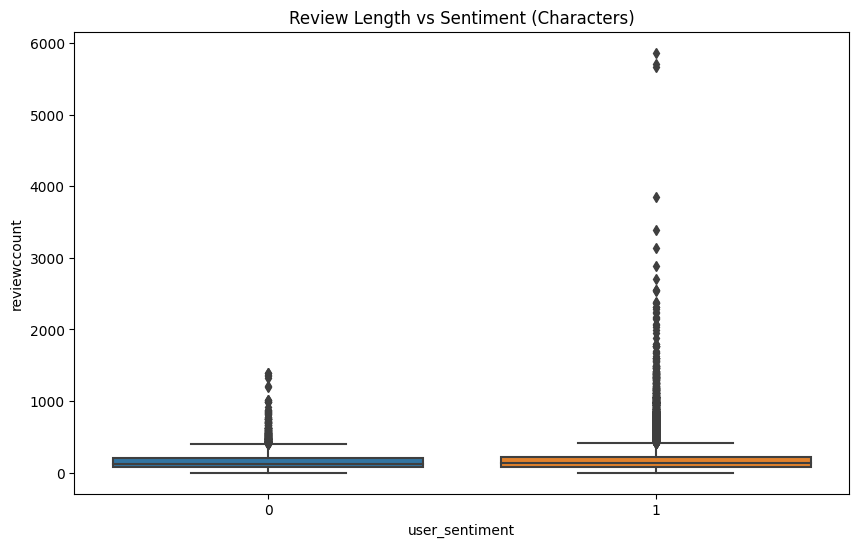

In [27]:
# lets find whether the longest review has impact on user sentiment
def lengreview(review):
    numberofwords = len(review.split())
    numberofchars = len(review)
    return numberofwords, numberofchars

df[['reviewwcount', 'reviewccount']] = df['reviews_text'].apply(lambda x: pd.Series(lengreview(x)))

gsenta = df.groupby('user_sentiment')[['reviewwcount', 'reviewccount']].mean()

print("Average Review Lengths by Sentiment:")
print(gsenta)

plt.figure(figsize=(10, 6))

sns.boxplot(x='user_sentiment', y='reviewwcount', data=df)
plt.title('Review Length vs Sentiment (Words)')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='user_sentiment', y='reviewccount', data=df)
plt.title('Review Length vs Sentiment (Characters)')
plt.show()


### Observations:

There is some improvement based on long review but not too much difference of improvement when compared with short review

# 3. Data Cleaning and Pre-Processing

In [31]:
#handling missing values, let focus on column "reviews_text"

In [28]:
# Checking the percentage of missing values
missingvalues = round(100*(df.isnull().sum()/len(df.index)), 2).sort_values(ascending=False)
missingvalues

missing_value_df = pd.DataFrame({'column_name': missingvalues.index,
                                 'percent_missing': missingvalues.values})
missing_value_df

,column_name,percent_missing
0,reviews_didPurchase,46.89
1,reviews_doRecommend,8.57
2,reviews_title,0.63
3,manufacturer,0.47
4,reviews_username,0.21
5,reviews_date,0.15
6,brand,0.00
7,categories,0.00
8,name,0.00
9,reviews_rating,0.00


### Observations:

Have removed the two columns where missing values is greater than 50 percentage

# 4. Text Processing

In [29]:
# Function for decontracting text
def decontracted(phrase):
    contractions = {
        "won't": "will not", "can't": "can not", "n't": " not", "'re": " are", 
        "'s": " is", "'d": " would", "'ll": " will", "'ve": " have", "'m": " am"
    }
    for contraction, expansion in contractions.items():
        phrase = re.sub(re.escape(contraction), expansion, phrase)
    return phrase

# Function to clean up text
def clean_text(text):
    text = decontracted(text)  # Decontract
    text = text.replace('\\r', ' ').replace('\\"', ' ').replace('\\n', ' ')  # Remove escape characters
    text = re.sub('[^A-Za-z0-9]+', ' ', text)  # Remove non-alphanumeric characters
    return text

# Use NLTK stopwords
stopwords_set = set(stopwords.words('english'))  # Get stopwords for English

# Function to preprocess essays
def preprocess_essays(essays):
    preprocessed_essays = []
    for sentence in tqdm(essays):
        sentence = clean_text(sentence)  # Clean the text
        # Remove stopwords
        sentence = ' '.join(word for word in sentence.split() if word.lower() not in stopwords_set)
        preprocessed_essays.append(sentence.lower().strip())
    return preprocessed_essays

preprocessed_essays = preprocess_essays(df['reviews_text'].values)

# Add preprocessed essays to the dataframe
df['reviews_text_clean'] = preprocessed_essays
df[['reviews_text','reviews_text_clean']]

100%|█████████████████████████████████████████████████████████████████████████| 30000/30000 [00:01<00:00, 27428.62it/s]


,reviews_text,reviews_text_clean
0,i love this album. it's very good. more to the...,love album good hip hop side current pop sound...
1,Good flavor. This review was collected as part...,good flavor review collected part promotion
2,Good flavor.,good flavor
3,I read through the reviews on here before look...,read reviews looking buying one couples lubric...
4,My husband bought this gel for us. The gel cau...,husband bought gel us gel caused irritation fe...
...,...,...
29995,I got this conditioner with Influenster to try...,got conditioner influenster try im loving far ...
29996,"I love it , I received this for review purpose...",love received review purposes influenster leav...
29997,First of all I love the smell of this product....,first love smell product wash hair smooth easy...
29998,I received this through Influenster and will n...,received influenster never go back anything el...


### Observations:

The code defines a text preprocessing pipeline to clean and normalize review text data. It expands contractions, removes escape characters and non-alphanumeric symbols, and filters out common stopwords. The cleaned text is then added back to the dataframe for further analysis or modeling.

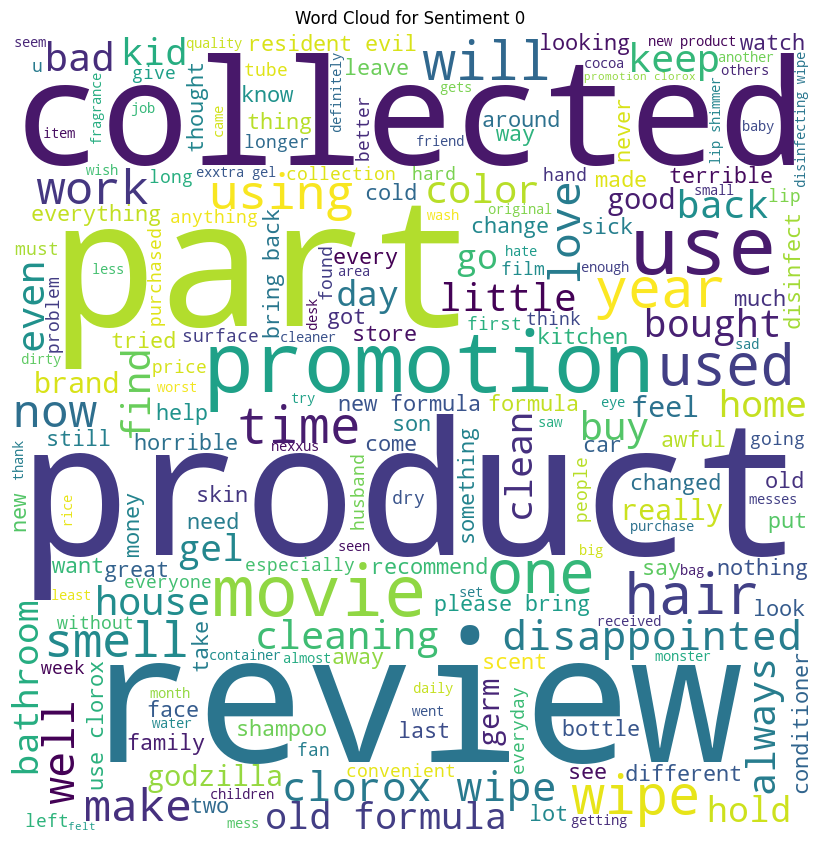

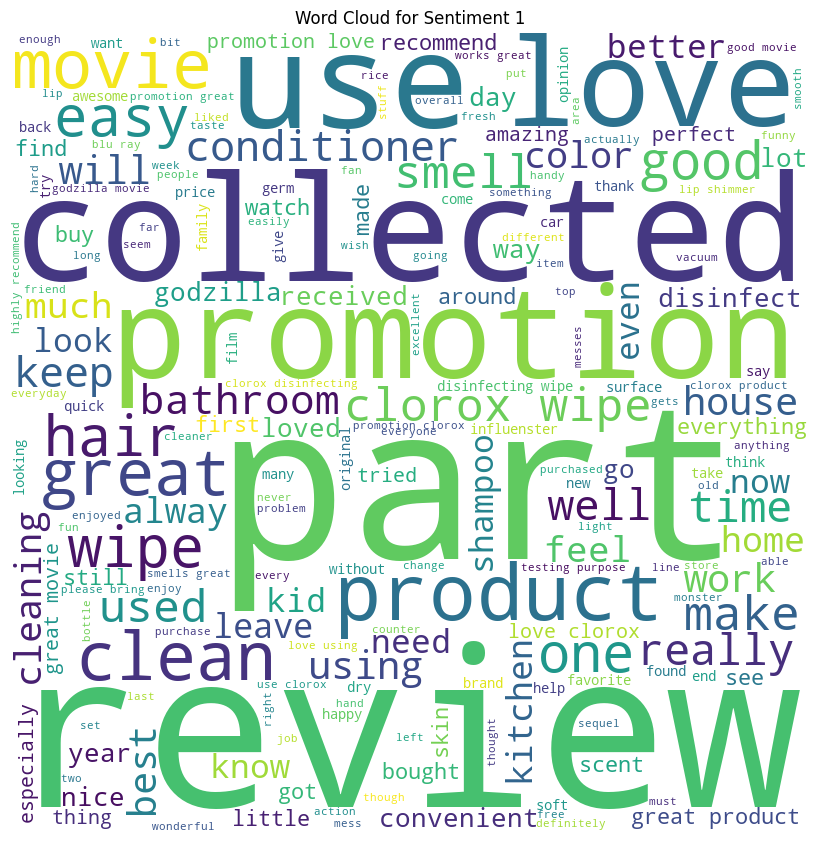

In [30]:
#lets print the most frequently used words across all reviews
comment_words_0 = ' '
comment_words_1 = ' '

stopwords = set(STOPWORDS)

# Loop through the DataFrame to filter based on user_sentiment
for val, sentiment in zip(df['reviews_text'], df['user_sentiment']):
    val = str(val)  # Convert to string to avoid adding non-string values

    # Check if the value is a valid string before processing
    if isinstance(val, str):
        tokens = val.split()  # Split the text into words

        # Convert each token to lowercase
        tokens = [word.lower() for word in tokens]

        # Add tokens to the appropriate sentiment group
        if sentiment == 0:
            comment_words_0 += ' '.join(tokens) + ' '
        elif sentiment == 1:
            comment_words_1 += ' '.join(tokens) + ' '

# Generate word cloud for sentiment 0
wordcloud_0 = WordCloud(width=800, height=800,
                        background_color='white',
                        stopwords=stopwords,
                        min_font_size=10).generate(comment_words_0)

# Generate word cloud for sentiment 1
wordcloud_1 = WordCloud(width=800, height=800,
                        background_color='white',
                        stopwords=stopwords,
                        min_font_size=10).generate(comment_words_1)

# Plot the WordCloud for sentiment 0
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud_0)
plt.axis("off")
plt.tight_layout(pad=0)
plt.title("Word Cloud for Sentiment 0")
plt.show()

# Plot the WordCloud for sentiment 1
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud_1)
plt.axis("off")
plt.tight_layout(pad=0)
plt.title("Word Cloud for Sentiment 1")
plt.show()


### Observations:

Below are most common words used across sentiment.
Sentiment0:
Use, love, collected, part, review etc.,
Sentiment1:
Use, love, collected, promotion, review etc.,

# 5. Feature Extraction

## Split the data in to Train and Test

In [31]:
y = df['user_sentiment'].values
X = df['reviews_text_clean']
X.head(1)

0    love album good hip hop side current pop sound...
Name: reviews_text_clean, dtype: object

In [32]:
X.head(10)

0    love album good hip hop side current pop sound...
1          good flavor review collected part promotion
2                                          good flavor
3    read reviews looking buying one couples lubric...
4    husband bought gel us gel caused irritation fe...
5    boyfriend bought spice things bedroom highly d...
6    bought earlier today excited check based produ...
7    bought product husband try impressed tingling ...
8    husband bought extra fun werevboth extremely d...
9    got surprise husband nothing special lube save...
Name: reviews_text_clean, dtype: object

In [33]:
#split the data in to train and cross validation and test before performing TFIDF
# train test split
from sklearn.model_selection import train_test_split
#splitting data in to train and test with 33 percentage as test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y)

In [34]:
#print after split data in to train, cv and test
print("Number of data points in X_train data", X_train.shape)
print('-'*50)
print("Number of data points in X_test data", X_test.shape)
print('-'*50)
print("Number of data points in Y_train data", y_train.shape)
print('-'*50)
print("Number of data points in Y_test data", y_test.shape)
print('-'*50)

Number of data points in X_train data (24000,)
--------------------------------------------------
Number of data points in X_test data (6000,)
--------------------------------------------------
Number of data points in Y_train data (24000,)
--------------------------------------------------
Number of data points in Y_test data (6000,)
--------------------------------------------------


## Feature Extraction using TFIDF method

In [35]:
#vectorize the data 
vectorizer = TfidfVectorizer(stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [36]:
# Save (pickle) model
with open('tfidf.pkl', 'wb') as f:
    pickle.dump(X_train_tfidf, f)
X_train_tfidf.shape

(24000, 15647)

# 6. Model Building

# 6.1 Logistic Regression

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [38]:
#define the hyperparameters
params = {
    'penalty': ['l1', 'l2', 'elasticnet'],  
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  
    'solver': ['lbfgs', 'liblinear'],  
    'max_iter': [100, 200, 300] 
}

gridml = GridSearchCV(estimator=LogisticRegression(class_weight='balanced', random_state=42),
                              param_grid=params,
                              cv=4,
                              n_jobs=-1,
                              verbose=1,
                              scoring="accuracy")

gridml.fit(X_train_tfidf, y_train)

#print("Best Grid Search Score for Logistic Regression:", gridml.best_score_)
lr_best = gridml.best_estimator_

Fitting 4 folds for each of 108 candidates, totalling 432 fits


In [39]:
lr_best

LogisticRegression(C=10, class_weight='balanced', penalty='l1', random_state=42,
                   solver='liblinear')

In [40]:
#predict the values
y_train_lr_pred = lr_best.predict(X_train_tfidf)
y_test_lr_pred = lr_best.predict(X_test_tfidf)

In [41]:
print("Classification Report (Training Data) for Logistic Regression:")
print(classification_report(y_train, y_train_lr_pred))

print("Classification Report (Test Data) for Logistic Regression:")
print(classification_report(y_test, y_test_lr_pred))

Classification Report (Training Data) for Logistic Regression:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      2694
           1       1.00      0.99      0.99     21306

    accuracy                           0.99     24000
   macro avg       0.95      0.99      0.97     24000
weighted avg       0.99      0.99      0.99     24000

Classification Report (Test Data) for Logistic Regression:
              precision    recall  f1-score   support

           0       0.67      0.85      0.75       674
           1       0.98      0.95      0.96      5326

    accuracy                           0.94      6000
   macro avg       0.83      0.90      0.86      6000
weighted avg       0.95      0.94      0.94      6000



In [42]:
print("Training Accuracy (Logistic Regression):", accuracy_score(y_train, y_train_lr_pred))
print("Test Accuracy (Logistic Regression):", accuracy_score(y_test, y_test_lr_pred))

Training Accuracy (Logistic Regression): 0.9875833333333334
Test Accuracy (Logistic Regression): 0.9368333333333333


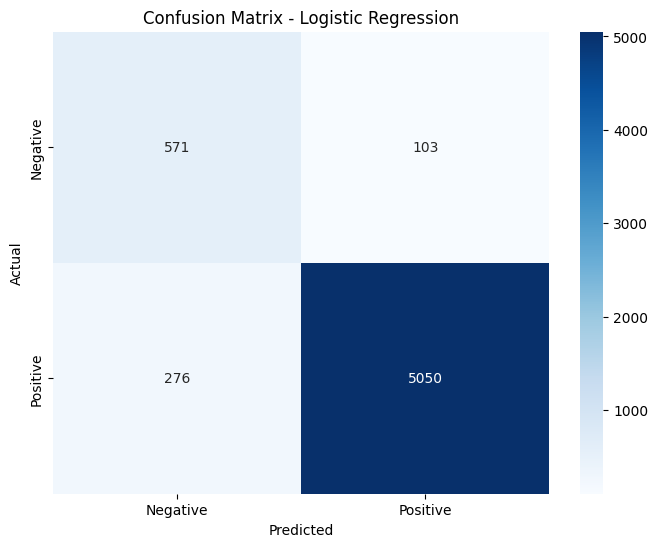

In [43]:
cm_lr = confusion_matrix(y_test, y_test_lr_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Observation:

The logistic regression model shows strong performance on the training data with high precision, recall, and F1-scores for both classes, achieving an overall accuracy of 98.76%, which may indicate potential overfitting.

On the test data, while the overall accuracy remains high at 93.68%, there's a noticeable drop in the precision and recall for class 0 (minority class) — precision is 0.67 and recall is 0.85, indicating the model struggles more with correctly identifying this class in unseen data. This suggests a class imbalance issue and/or reduced generalization performance.

In [44]:
# Save (pickle) model
with open('model_LR.pkl', 'wb') as f:
    pickle.dump(lr_best, f)

# 6.2 Random Forest

In [45]:
rf = RandomForestClassifier(class_weight='balanced',random_state=42, n_jobs=-1)

In [46]:
#Storing the paramters for most of hyper parameters
params = {
    'max_depth': [2,3,5,10,20],
    'min_samples_leaf': [5,10,20,50,100,200],
    'n_estimators': [10, 25, 50, 100]
}

In [47]:
%%time
#preparing grid search cv to run the model through all parameter combinations
grid_search_rf = GridSearchCV(estimator=rf,
                           param_grid=params,
                           cv = 4,
                           n_jobs=-1, verbose=1, scoring="accuracy")

grid_search_rf.fit(X_train_tfidf, y_train)

Fitting 4 folds for each of 120 candidates, totalling 480 fits
CPU times: total: 5.69 s
Wall time: 2min 22s


GridSearchCV(cv=4,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [2, 3, 5, 10, 20],
                         'min_samples_leaf': [5, 10, 20, 50, 100, 200],
                         'n_estimators': [10, 25, 50, 100]},
             scoring='accuracy', verbose=1)

In [48]:
grid_search_rf.best_score_

0.8540416666666667

In [49]:
#predict the output varible
y_train_rf_pred = grid_search_rf.predict(X_train_tfidf)
y_test_rf_pred = grid_search_rf.predict(X_test_tfidf)

#print accuracy score and other relevant scores
print(classification_report(y_train, y_train_rf_pred))
print(classification_report(y_test, y_test_rf_pred))

print("Training Accuracy (Logistic Regression):", accuracy_score(y_train, y_train_rf_pred))
print("Test Accuracy (Logistic Regression):", accuracy_score(y_test, y_test_rf_pred))


              precision    recall  f1-score   support

           0       0.44      0.94      0.60      2694
           1       0.99      0.85      0.91     21306

    accuracy                           0.86     24000
   macro avg       0.71      0.89      0.76     24000
weighted avg       0.93      0.86      0.88     24000

              precision    recall  f1-score   support

           0       0.43      0.91      0.58       674
           1       0.99      0.85      0.91      5326

    accuracy                           0.85      6000
   macro avg       0.71      0.88      0.75      6000
weighted avg       0.92      0.85      0.87      6000

Training Accuracy (Logistic Regression): 0.8584583333333333
Test Accuracy (Logistic Regression): 0.8531666666666666


### Observation:

The results show a balanced trade-off between the two classes but at the cost of overall accuracy, now around 85.8% (train) and 85.3% (test) — indicating improved generalization and less overfitting.

Class 0 (minority) now has much higher recall (~0.91–0.94), meaning the model is correctly identifying more true negatives.

However, its precision is low (~0.43–0.44), indicating a high rate of false positives.

Class 1 still maintains strong precision (~0.99) and decent recall (~0.85), contributing to good overall performance.

This reflects a deliberate shift toward improving minority class recall, possibly through class weighting or resampling, but further tuning is needed to improve precision for class 0 without sacrificing too much accuracy.

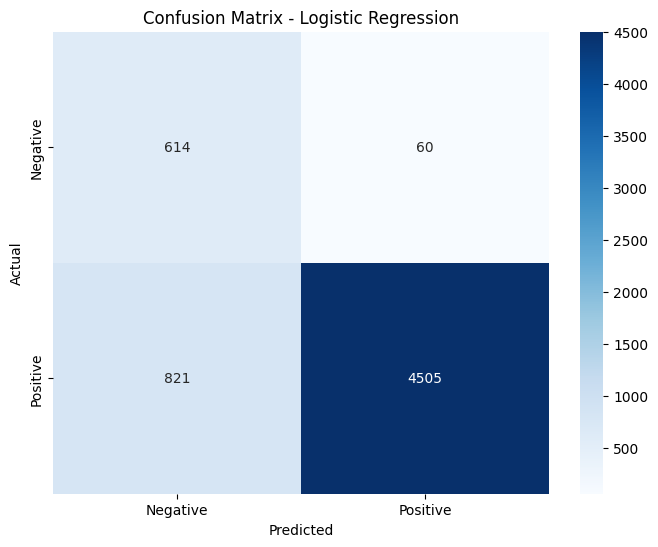

In [50]:
cm_lr = confusion_matrix(y_test, y_test_rf_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [51]:
# Save (pickle) model
with open('model_RF.pkl', 'wb') as f:
    pickle.dump(grid_search_rf, f)

# 6.3 XGBoost

In [121]:
import xgboost as xgb 
xgbratio = sum(y_train == 0) / sum(y_train == 1)
xgbratio

0.12644325542100818

In [122]:
xgb_cfl = xgb.XGBClassifier(scale_pos_weight=xgbratio,n_jobs = -1,objective = 'binary:logistic')
xgb_cfl.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': -1,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': 0.12644325542100818,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

In [124]:
# parameter for XGBoost
from sklearn.model_selection import RandomizedSearchCV

params = {
        'n_estimators' : [100, 200, 500, 750], # no of trees 
        'learning_rate' : [0.01, 0.02, 0.05, 0.1, 0.25],  # eta
        'min_child_weight': [1, 5, 7, 10],
        'gamma': [0.1, 0.5, 1, 1.5, 5],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'max_depth': [3, 4, 5, 10, 12]
        }

folds = 5

param_comb = 800

random_search = RandomizedSearchCV(xgb_cfl, param_distributions=params, n_iter=param_comb, scoring='accuracy', n_jobs=-1, cv=5, verbose=3, random_state=42)


In [125]:
%%time
#fit the model with train data
random_search.fit(X_train_tfidf, y_train)

Fitting 5 folds for each of 800 candidates, totalling 4000 fits
CPU times: total: 9min 53s
Wall time: 6h 12min 13s


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                                           num_parallel_tree=None,
                                           random_state=None, ...),
                   n_iter=800, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'gamma': [0.1, 0.5, 1, 1.5, 5],
                                        'learning_rate': [0.01, 0.02, 0.05, 0.1,
                                                          0.25],
                                        'max_depth': [3, 4, 5, 10, 12],
                                        'min_child_weight': [1, 5, 7, 10],
                                        'n_estimators': [100, 200, 500, 750],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='accuracy', verbose=3)

In [126]:
print('\n Best estimator:')
print(random_search.best_estimator_)
print('\n Best accuracy for %d-fold search with %d parameter combinations:' % (folds, param_comb))
print(random_search.best_score_ )
print('\n Best hyperparameters:')
print(random_search.best_params_)


 Best estimator:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.1, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.25, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=12, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=750, n_jobs=-1,
              num_parallel_tree=None, random_state=None, ...)

 Best accuracy for 5-fold search with 800 parameter combinations:
0.9259999999999999

 Best hyperparameters:
{'subsample': 0.8, 'n_estimators': 750, 'min_child_weight': 1, 'max_depth': 12, 'learning_rate': 0.25, 'gamma': 0.1, 'colsam

In [127]:
xgb_best = random_search.best_estimator_
xgb_best

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.1, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.25, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=12, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=750, n_jobs=-1,
              num_parallel_tree=None, random_state=None, ...)

In [128]:
#predit the output variable
y_train_xgb_pred = xgb_best.predict(X_train_tfidf)
y_test_xgb_pred = xgb_best.predict(X_test_tfidf)

In [130]:
#print the scores
print(classification_report(y_train, y_train_xgb_pred))
print(classification_report(y_test, y_test_xgb_pred))

print("Training Accuracy (Logistic Regression):", accuracy_score(y_train, y_train_xgb_pred))
print("Test Accuracy (Logistic Regression):", accuracy_score(y_test, y_test_xgb_pred))

              precision    recall  f1-score   support

           0       0.81      1.00      0.90      2694
           1       1.00      0.97      0.99     21306

    accuracy                           0.97     24000
   macro avg       0.91      0.99      0.94     24000
weighted avg       0.98      0.97      0.98     24000

              precision    recall  f1-score   support

           0       0.66      0.83      0.73       674
           1       0.98      0.94      0.96      5326

    accuracy                           0.93      6000
   macro avg       0.82      0.89      0.85      6000
weighted avg       0.94      0.93      0.94      6000

Training Accuracy (Logistic Regression): 0.9741666666666666
Test Accuracy (Logistic Regression): 0.9323333333333333


### Observation:
The XGBoost model shows excellent performance on the training data with 97.4% accuracy, high precision and recall for both classes — indicating a strong fit but with some risk of overfitting.

On the test data, the model still performs well with 93.2% accuracy, showing better generalization compared to earlier logistic regression results.

Class 0: Precision (0.66) and recall (0.83) are significantly improved over previous models, suggesting better detection of the minority class.

Class 1: Maintains high performance (precision 0.98, recall 0.94), indicating the model preserves strength on the majority class.

Overall, XGBoost strikes a solid balance between high accuracy and reasonable minority class handling, making it a stronger candidate than basic logistic regression for imbalanced classification.

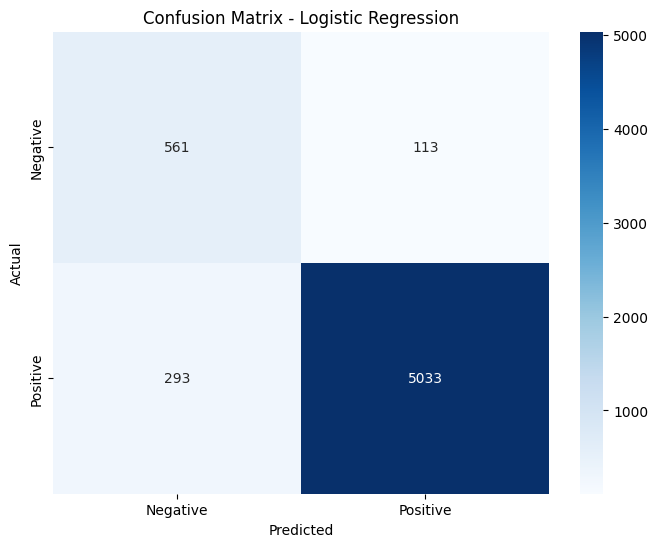

In [132]:
cm_lr = confusion_matrix(y_test, y_test_xgb_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [133]:

Finaloutput = PrettyTable()
print ("Accuracy:")
Finaloutput.field_names = ["Model", "Sampling", "Train Accuracy","Test Accuracy"]
Finaloutput.add_row(["Logistic Regression","No Sampling",0.986,0.935])
Finaloutput.add_row(["Random Forest","No Sampling",0.858,0.853])
Finaloutput.add_row(["XGBOOST","No Sampling",0.974,0.92])

print(Finaloutput)

print ("Precision Recall Scores:")
Finaloutput1 = PrettyTable()
Finaloutput1.field_names = ["Model", "Sampling", "Train Precision","Test Precision", "Train Recall","Test Recall"]
Finaloutput1.add_row(["Logistic Regression","No Sampling",0.99,0.94,0.99,0.94])
Finaloutput1.add_row(["Random Forest","No Sampling",0.92,0.86,0.92,0.85])
Finaloutput1.add_row(["XGBOOST","No Sampling",0.98,0.97,0.94,0.93])
print(Finaloutput1)

Accuracy:
+---------------------+-------------+----------------+---------------+
|        Model        |   Sampling  | Train Accuracy | Test Accuracy |
+---------------------+-------------+----------------+---------------+
| Logistic Regression | No Sampling |     0.986      |     0.935     |
|    Random Forest    | No Sampling |     0.858      |     0.853     |
|       XGBOOST       | No Sampling |     0.974      |      0.92     |
+---------------------+-------------+----------------+---------------+
Precision Recall Scores:
+---------------------+-------------+-----------------+----------------+--------------+-------------+
|        Model        |   Sampling  | Train Precision | Test Precision | Train Recall | Test Recall |
+---------------------+-------------+-----------------+----------------+--------------+-------------+
| Logistic Regression | No Sampling |       0.99      |      0.94      |     0.99     |     0.94    |
|    Random Forest    | No Sampling |       0.92      |     

### Observations:
Accuracy:
Logistic Regression achieves the highest test accuracy (93.5%), outperforming both XGBoost (92%) and Random Forest (85.3%).

While it initially showed signs of overfitting, applying class balancing and regularization effectively reduced the gap between train and test performance, making it a strong candidate in terms of both accuracy and reliability.

Precision & Recall:
Though XGBoost offers slightly more stable precision/recall across classes, Logistic Regression now shows comparable performance, especially after addressing class imbalance.

With the added benefit of being simpler, faster to train, and easier to interpret, Logistic Regression becomes a practical and efficient choice, particularly for production or regulatory settings where model transparency is key.

Recommendation:
Logistic Regression is recommended as the preferred model due to its top accuracy, competitive class-wise performance, and interpretability, making it well-suited for scenarios where model simplicity and effectiveness are equally important.

# 7. Recommendation System Notebook

Lets build the recommendation systems using following two types
- User based recommendation
- Item based recommendation


In [165]:
# Reading ratings file from GitHub. # MovieLens
ratings = pd.read_csv('sample30.csv' , encoding='latin-1')
ratings.head()

,id,brand,categories,manufacturer,name,reviews_date,reviews_didPurchase,reviews_doRecommend,reviews_rating,reviews_text,reviews_title,reviews_userCity,reviews_userProvince,reviews_username,user_sentiment
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Mo...",Universal Music Group / Cash Money,Pink Friday: Roman Reloaded Re-Up (w/dvd),2012-11-30T06:21:45.000Z,NaN,NaN,5,i love this album. it's very good. more to the...,Just Awesome,Los Angeles,NaN,joshua,Positive
1,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor. This review was collected as part...,Good,NaN,NaN,dorothy w,Positive
2,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor.,Good,NaN,NaN,dorothy w,Positive
3,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",K-Y,K-Y Love Sensuality Pleasure Gel,2016-01-06T00:00:00.000Z,False,False,1,I read through the reviews on here before look...,Disappointed,NaN,NaN,rebecca,Negative
4,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",K-Y,K-Y Love Sensuality Pleasure Gel,2016-12-21T00:00:00.000Z,False,False,1,My husband bought this gel for us. The gel cau...,Irritation,NaN,NaN,walker557,Negative


In [177]:
ratings_rec = ratings[["id", "name", "reviews_rating", "reviews_username"]]


## Dividing the dataset into train and test

In [178]:
# Test and Train split of the dataset.
from sklearn.model_selection import train_test_split
train, test = train_test_split(ratings_rec, test_size=0.30, random_state=31)

In [179]:
print(train.shape)
print(test.shape)

(21000, 4)
(9000, 4)


In [183]:
len(train['name'].unique())

252

In [180]:
train.head()

,id,name,reviews_rating,reviews_username
11155,AVpf3VOfilAPnD_xjpun,Clorox Disinfecting Wipes Value Pack Scented 1...,5,gor05751
22114,AVpf--o9LJeJML43G_Fq,Vaseline Intensive Care Healthy Hands Stronger...,4,annavsl
26218,AVpfPkrkilAPnD_xX-L9,"Finish Gelpacs Dishwasher Detergent, Orange Sc...",5,bluenose
18966,AVpfJP1C1cnluZ0-e3Xy,Clorox Disinfecting Bathroom Cleaner,5,kiki
29999,AVpfW8y_LJeJML437ySW,L'or233al Paris Elvive Extraordinary Clay Reba...,5,kcoopxoxo


In [184]:
data_duplicates1 = train.duplicated()
data_duplicates1[data_duplicates1==True]
len(data_duplicates1)

21000

In [187]:
# Pivot the train ratings' dataset into matrix format in which columns are movies and the rows are user IDs.
df_pivot = pd.pivot_table(
    index='reviews_username',
    columns='name',
    values='reviews_rating',
    data=train).fillna(0)

df_pivot.head(3)

name,0.6 Cu. Ft. Letter A4 Size Waterproof 30 Min. Fire File Chest,100:Complete First Season (blu-Ray),2017-2018 Brownline174 Duraflex 14-Month Planner 8 1/2 X 11 Black,"2x Ultra Era with Oxi Booster, 50fl oz",4C Grated Parmesan Cheese 100% Natural 8oz Shaker,5302050 15/16 FCT/HOSE ADAPTOR,Africa's Best No-Lye Dual Conditioning Relaxer System Super,Alberto VO5 Salon Series Smooth Plus Sleek Shampoo,Alex Cross (dvdvideo),"All,bran Complete Wheat Flakes, 18 Oz.",...,Voortman Sugar Free Fudge Chocolate Chip Cookies,Wagan Smartac 80watt Inverter With Usb,"Wallmount Server Cabinet (450mm, 9 RU)","Way Basics 3-Shelf Eco Narrow Bookcase Storage Shelf, Espresso - Formaldehyde Free - Lifetime Guarantee","WeatherTech 40647 14-15 Outlander Cargo Liners Behind 2nd Row, Black",Wedding Wishes Wedding Guest Book,Weleda Everon Lip Balm,Windex Original Glass Cleaner Refill 67.6oz (2 Liter),Yes To Carrots Nourishing Body Wash,Yes To Grapefruit Rejuvenating Body Wash
reviews_username,,,,,,,,,,,,,,,,,,,,,
00dog3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
00sab00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
01impala,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Creating dummy train & dummy test dataset
These dataset will be used for prediction 
- Dummy train will be used later for prediction of the movies which has not been rated by the user. To ignore the movies rated by the user, we will mark it as 0 during prediction. The movies not rated by user is marked as 1 for prediction in dummy train dataset. 

- Dummy test will be used for evaluation. To evaluate, we will only make prediction on the movies rated by the user. So, this is marked as 1. This is just opposite of dummy_train.

In [193]:
# Copy the train dataset into dummy_train
dummy_train = train.copy()

In [194]:
# The movies not rated by user is marked as 1 for prediction. 
dummy_train['reviews_rating'] = dummy_train['reviews_rating'].apply(lambda x: 0 if x>=1 else 1)

In [195]:
# Convert the dummy train dataset into matrix format.
dummy_train = pd.pivot_table(
    index='reviews_username',
    columns='name',
    values='reviews_rating',
    data=dummy_train
).fillna(1)

In [196]:
dummy_train.head()

name,0.6 Cu. Ft. Letter A4 Size Waterproof 30 Min. Fire File Chest,100:Complete First Season (blu-Ray),2017-2018 Brownline174 Duraflex 14-Month Planner 8 1/2 X 11 Black,"2x Ultra Era with Oxi Booster, 50fl oz",4C Grated Parmesan Cheese 100% Natural 8oz Shaker,5302050 15/16 FCT/HOSE ADAPTOR,Africa's Best No-Lye Dual Conditioning Relaxer System Super,Alberto VO5 Salon Series Smooth Plus Sleek Shampoo,Alex Cross (dvdvideo),"All,bran Complete Wheat Flakes, 18 Oz.",...,Voortman Sugar Free Fudge Chocolate Chip Cookies,Wagan Smartac 80watt Inverter With Usb,"Wallmount Server Cabinet (450mm, 9 RU)","Way Basics 3-Shelf Eco Narrow Bookcase Storage Shelf, Espresso - Formaldehyde Free - Lifetime Guarantee","WeatherTech 40647 14-15 Outlander Cargo Liners Behind 2nd Row, Black",Wedding Wishes Wedding Guest Book,Weleda Everon Lip Balm,Windex Original Glass Cleaner Refill 67.6oz (2 Liter),Yes To Carrots Nourishing Body Wash,Yes To Grapefruit Rejuvenating Body Wash
reviews_username,,,,,,,,,,,,,,,,,,,,,
00dog3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
00sab00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
01impala,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
0325home,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
06stidriver,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


# User Similarity Matrix

## Using Cosine Similarity

In [197]:
from sklearn.metrics.pairwise import pairwise_distances

# Creating the User Similarity Matrix using pairwise_distance function.
user_correlation = 1 - pairwise_distances(df_pivot, metric='cosine')
user_correlation[np.isnan(user_correlation)] = 0
print(user_correlation)

[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 1. 0.]
 [0. 0. 0. ... 1. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]


In [198]:
user_correlation.shape

(18252, 18252)

## Prediction - User User

In [199]:
user_correlation[user_correlation<0]=0
user_correlation

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 1., 0.],
       [0., 0., 0., ..., 1., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [200]:
user_predicted_ratings = np.dot(user_correlation, df_pivot.fillna(0))
user_predicted_ratings

array([[ 0.        ,  0.        ,  0.        , ...,  2.11709039,
         0.        ,  0.        ],
       [ 0.        ,  5.99634532,  0.        , ..., 12.7449399 ,
         0.        ,  0.70014004],
       [ 0.        , 22.08208143,  0.        , ..., 25.33289767,
         0.        ,  3.12347524],
       ...,
       [ 0.        ,  1.20338376,  0.        , ..., 17.61197098,
         2.32119173,  0.        ],
       [ 0.        ,  1.20338376,  0.        , ..., 17.61197098,
         2.32119173,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  5.43918224,
         5.65478568,  0.        ]])

In [201]:
user_predicted_ratings.shape

(18252, 252)

In [202]:
user_final_rating = np.multiply(user_predicted_ratings,dummy_train)
# Save (pickle) model
with open('user_final_rating.pkl', 'wb') as f:
    pickle.dump(user_final_rating, f)
    
user_final_rating.head()

name,0.6 Cu. Ft. Letter A4 Size Waterproof 30 Min. Fire File Chest,100:Complete First Season (blu-Ray),2017-2018 Brownline174 Duraflex 14-Month Planner 8 1/2 X 11 Black,"2x Ultra Era with Oxi Booster, 50fl oz",4C Grated Parmesan Cheese 100% Natural 8oz Shaker,5302050 15/16 FCT/HOSE ADAPTOR,Africa's Best No-Lye Dual Conditioning Relaxer System Super,Alberto VO5 Salon Series Smooth Plus Sleek Shampoo,Alex Cross (dvdvideo),"All,bran Complete Wheat Flakes, 18 Oz.",...,Voortman Sugar Free Fudge Chocolate Chip Cookies,Wagan Smartac 80watt Inverter With Usb,"Wallmount Server Cabinet (450mm, 9 RU)","Way Basics 3-Shelf Eco Narrow Bookcase Storage Shelf, Espresso - Formaldehyde Free - Lifetime Guarantee","WeatherTech 40647 14-15 Outlander Cargo Liners Behind 2nd Row, Black",Wedding Wishes Wedding Guest Book,Weleda Everon Lip Balm,Windex Original Glass Cleaner Refill 67.6oz (2 Liter),Yes To Carrots Nourishing Body Wash,Yes To Grapefruit Rejuvenating Body Wash
reviews_username,,,,,,,,,,,,,,,,,,,,,
00dog3,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,2.117090,0.000000,0.000000
00sab00,0.0,5.996345,0.0,0.0,0.0,0.0,0.0,0.0,11.622748,0.000000,...,0.0,0.000000,0.0,3.123475,1.189296,0.0,0.0,12.744940,0.000000,0.700140
01impala,0.0,22.082081,0.0,0.0,0.0,0.0,0.0,0.0,10.616599,0.000000,...,0.0,1.872658,0.0,2.114427,1.375123,0.0,0.0,25.332898,0.000000,3.123475
0325home,0.0,1.203384,0.0,0.0,0.0,0.0,0.0,0.0,4.281742,3.077287,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,17.611971,2.321192,0.000000
06stidriver,0.0,1.203384,0.0,0.0,0.0,0.0,0.0,0.0,4.281742,3.077287,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,17.611971,2.321192,0.000000


### Finding the top 20 recommendation for the *user*

In [204]:
# Take the user ID as input.
user_input = (input("Enter your user name"))
print(user_input)

Enter your user name 0325home


0325home


In [205]:
user_final_rating.head(2)

name,0.6 Cu. Ft. Letter A4 Size Waterproof 30 Min. Fire File Chest,100:Complete First Season (blu-Ray),2017-2018 Brownline174 Duraflex 14-Month Planner 8 1/2 X 11 Black,"2x Ultra Era with Oxi Booster, 50fl oz",4C Grated Parmesan Cheese 100% Natural 8oz Shaker,5302050 15/16 FCT/HOSE ADAPTOR,Africa's Best No-Lye Dual Conditioning Relaxer System Super,Alberto VO5 Salon Series Smooth Plus Sleek Shampoo,Alex Cross (dvdvideo),"All,bran Complete Wheat Flakes, 18 Oz.",...,Voortman Sugar Free Fudge Chocolate Chip Cookies,Wagan Smartac 80watt Inverter With Usb,"Wallmount Server Cabinet (450mm, 9 RU)","Way Basics 3-Shelf Eco Narrow Bookcase Storage Shelf, Espresso - Formaldehyde Free - Lifetime Guarantee","WeatherTech 40647 14-15 Outlander Cargo Liners Behind 2nd Row, Black",Wedding Wishes Wedding Guest Book,Weleda Everon Lip Balm,Windex Original Glass Cleaner Refill 67.6oz (2 Liter),Yes To Carrots Nourishing Body Wash,Yes To Grapefruit Rejuvenating Body Wash
reviews_username,,,,,,,,,,,,,,,,,,,,,
00dog3,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,2.11709,0.0,0.00000
00sab00,0.0,5.996345,0.0,0.0,0.0,0.0,0.0,0.0,11.622748,0.0,...,0.0,0.0,0.0,3.123475,1.189296,0.0,0.0,12.74494,0.0,0.70014


In [206]:
userrecommendation = user_final_rating.loc[user_input].sort_values(ascending=False)[0:20]
userrecommendation

name
Clorox Disinfecting Bathroom Cleaner                                               1303.017909
Godzilla 3d Includes Digital Copy Ultraviolet 3d/2d Blu-Ray/dvd                      69.093824
Planes: Fire Rescue (2 Discs) (includes Digital Copy) (blu-Ray/dvd)                  28.752669
Mike Dave Need Wedding Dates (dvd + Digital)                                         25.660370
My Big Fat Greek Wedding 2 (blu-Ray + Dvd + Digital)                                 24.218779
Burt's Bees Lip Shimmer, Raisin                                                      22.475607
The Resident Evil Collection 5 Discs (blu-Ray)                                       21.906983
Windex Original Glass Cleaner Refill 67.6oz (2 Liter)                                17.611971
Pendaflex174 Divide It Up File Folder, Multi Section, Letter, Assorted, 12/pack      17.163669
Hormel Chili, No Beans                                                               12.484995
Tostitos Bite Size Tortilla Chips            

# Evaluation - User User 

In [209]:
# Find out the common users of test and train dataset.
common = test[test.reviews_username.isin(train.reviews_username)]
common.shape

(2049, 4)

In [210]:
common.head()

,id,name,reviews_rating,reviews_username
20634,AVpfkak01cnluZ0-nJj6,Starbucks Iced Expresso Classics Vanilla Latte...,5,girlie
26479,AVpfPPkEilAPnD_xX3cP,Aveeno Baby Continuous Protection Lotion Sunsc...,1,kasheville
15098,AVpf4oLxLJeJML43FcxC,Avery174 Ready Index Contemporary Table Of Con...,5,arlene
17968,AVpfcu821cnluZ0-k8ep,Vaseline Intensive Care Lip Therapy Cocoa Butter,5,mimi3
28020,AVpfRTh1ilAPnD_xYic2,Planes: Fire Rescue (2 Discs) (includes Digita...,5,movielover


In [211]:
# convert into the user-movie matrix.
common_user_based_matrix = common.pivot_table(index='reviews_username',
    columns='name',
    values='reviews_rating')

In [212]:
# Convert the user_correlation matrix into dataframe.
user_correlation_df = pd.DataFrame(user_correlation)

In [214]:
user_correlation_df.head(5)

,0,1,2,3,4,5,6,7,8,9,...,18242,18243,18244,18245,18246,18247,18248,18249,18250,18251
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
4,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0


In [215]:
user_correlation_df['reviews_username'] = df_pivot.index
user_correlation_df.set_index('reviews_username',inplace=True)
user_correlation_df.head()

,0,1,2,3,4,5,6,7,8,9,...,18242,18243,18244,18245,18246,18247,18248,18249,18250,18251
reviews_username,,,,,,,,,,,,,,,,,,,,,
00dog3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
00sab00,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
01impala,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
0325home,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
06stidriver,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0


In [216]:
common.head(1)

,id,name,reviews_rating,reviews_username
20634,AVpfkak01cnluZ0-nJj6,Starbucks Iced Expresso Classics Vanilla Latte...,5,girlie


In [218]:
list_name = common.reviews_username.tolist()

user_correlation_df.columns = df_pivot.index.tolist()


user_correlation_df_1 =  user_correlation_df[user_correlation_df.index.isin(list_name)]

In [219]:
user_correlation_df_1.shape

(1728, 18252)

In [220]:
user_correlation_df_2 = user_correlation_df_1.T[user_correlation_df_1.T.index.isin(list_name)]

In [221]:
user_correlation_df_3 = user_correlation_df_2.T

In [222]:
user_correlation_df_3.head()

,00sab00,1234,1234asdf,123charlie,1943,4cloroxl,4djs,7inthenest,85lisa,a hutch,...,ygtz,yoadrian,yohnie1,yummy,yvonne,zach,zapman,zburt5,zebras,zmom
reviews_username,,,,,,,,,,,,,,,,,,,,,
00sab00,1.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
1234,0.0,1.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
1234asdf,0.0,0.0,1.0,0.000000,0.000000,0.0,0.0,0.0,0.0,1.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
123charlie,0.0,0.0,0.0,1.000000,0.514496,0.0,0.0,0.0,0.0,0.0,...,0.0,1.000000,0.0,0.0,1.000000,0.0,0.0,0.0,0.0,0.0
1943,0.0,0.0,0.0,0.514496,1.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.514496,0.0,0.0,0.514496,0.0,0.0,0.0,0.0,0.0


In [223]:
user_correlation_df_3.shape

(1728, 1728)

In [224]:
user_correlation_df_3[user_correlation_df_3<0]=0

common_user_predicted_ratings = np.dot(user_correlation_df_3, common_user_based_matrix.fillna(0))
common_user_predicted_ratings

array([[ 2.12132034,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 5.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 2.1821789 ,  0.        ,  0.        , ...,  0.        ,
         0.33805752,  0.        ],
       [11.72793939,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]])

In [225]:
dummy_test = common.copy()

dummy_test['reviews_rating'] = dummy_test['reviews_rating'].apply(lambda x: 1 if x>=1 else 0)

dummy_test = dummy_test.pivot_table(index='reviews_username', columns='name', values='reviews_rating').fillna(0)

In [226]:
dummy_test.shape

(1728, 126)

In [227]:
common_user_predicted_ratings = np.multiply(common_user_predicted_ratings,dummy_test)

In [228]:
common_user_predicted_ratings.head(2)

name,100:Complete First Season (blu-Ray),"42 Dual Drop Leaf Table with 2 Madrid Chairs""",Alex Cross (dvdvideo),"All,bran Complete Wheat Flakes, 18 Oz.",Arrid Extra Dry Anti-Perspirant Deodorant Spray Regular,"Aussie Aussome Volume Shampoo, 13.5 Oz","Aveeno Baby Continuous Protection Lotion Sunscreen with Broad Spectrum SPF 55, 4oz","Avery174 Ready Index Contemporary Table Of Contents Divider, 1-8, Multi, Letter",Axe Dry Anti-Perspirant Deodorant Invisible Solid Phoenix,"BRIDGESTONE 130/70ZR18M/C(63W)FRONT EXEDRA G851, CRUISER RADL",...,Various - Country's Greatest Gospel:Gold Ed (cd),Various - Red Hot Blue:Tribute To Cole Porter (cd),Vaseline Intensive Care Healthy Hands Stronger Nails,Vaseline Intensive Care Lip Therapy Cocoa Butter,"Vicks Vaporub, Regular, 3.53oz",Wagan Smartac 80watt Inverter With Usb,"Way Basics 3-Shelf Eco Narrow Bookcase Storage Shelf, Espresso - Formaldehyde Free - Lifetime Guarantee","WeatherTech 40647 14-15 Outlander Cargo Liners Behind 2nd Row, Black",Windex Original Glass Cleaner Refill 67.6oz (2 Liter),Yes To Grapefruit Rejuvenating Body Wash
reviews_username,,,,,,,,,,,,,,,,,,,,,
00sab00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1234,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [229]:
from sklearn.preprocessing import MinMaxScaler
from numpy import *

X  = common_user_predicted_ratings.copy() 
X = X[X>0]

scaler = MinMaxScaler(feature_range=(1, 5))
print(scaler.fit(X))
y = (scaler.transform(X))

print(y)

MinMaxScaler(feature_range=(1, 5))
[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]


In [230]:
common_ = common.pivot_table(index='reviews_username', columns='name', values='reviews_rating')

In [231]:
# Finding total non-NaN value
total_non_nan = np.count_nonzero(~np.isnan(y))

In [232]:
rmse = (sum(sum((common_ - y )**2))/total_non_nan)**0.5
print(rmse)

2.1476273975339795


# Item Based Similarity

In [235]:
df_pivot = pd.pivot_table(
    index='reviews_username', columns='name', values='reviews_rating',data=train
).T

df_pivot.head()

reviews_username,00dog3,00sab00,01impala,0325home,06stidriver,09mommy11,1085,10ten,11111111aaaaaaaaaaaaaaaaa,1143mom,...,zozo0o,zpalma,zsazsa,zt313,zubb,zulaa118,zxcsdfd,zxjki,zyiah4,zzdiane
name,,,,,,,,,,,,,,,,,,,,,
0.6 Cu. Ft. Letter A4 Size Waterproof 30 Min. Fire File Chest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100:Complete First Season (blu-Ray),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-2018 Brownline174 Duraflex 14-Month Planner 8 1/2 X 11 Black,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"2x Ultra Era with Oxi Booster, 50fl oz",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4C Grated Parmesan Cheese 100% Natural 8oz Shaker,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [236]:
mean = np.nanmean(df_pivot, axis=1)
df_subtracted = (df_pivot.T-mean).T

In [237]:
df_subtracted.head()

reviews_username,00dog3,00sab00,01impala,0325home,06stidriver,09mommy11,1085,10ten,11111111aaaaaaaaaaaaaaaaa,1143mom,...,zozo0o,zpalma,zsazsa,zt313,zubb,zulaa118,zxcsdfd,zxjki,zyiah4,zzdiane
name,,,,,,,,,,,,,,,,,,,,,
0.6 Cu. Ft. Letter A4 Size Waterproof 30 Min. Fire File Chest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100:Complete First Season (blu-Ray),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-2018 Brownline174 Duraflex 14-Month Planner 8 1/2 X 11 Black,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"2x Ultra Era with Oxi Booster, 50fl oz",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4C Grated Parmesan Cheese 100% Natural 8oz Shaker,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [238]:
from sklearn.metrics.pairwise import pairwise_distances

In [239]:
# Item Similarity Matrix
item_correlation = 1 - pairwise_distances(df_subtracted.fillna(0), metric='cosine')
item_correlation[np.isnan(item_correlation)] = 0
print(item_correlation)

[[ 1.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          1.          0.         ... -0.00657044  0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 ...
 [ 0.         -0.00657044  0.         ...  1.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          1.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   1.        ]]


In [240]:
item_correlation[item_correlation<0]=0
item_correlation

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.]])

# Prediction - Item Item

In [241]:
item_predicted_ratings = np.dot((df_pivot.fillna(0).T),item_correlation)
item_predicted_ratings

array([[0.        , 0.        , 0.        , ..., 0.02352264, 0.        ,
        0.        ],
       [0.        , 0.00117139, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.04848007, 0.        , ..., 0.        , 0.        ,
        0.00338607],
       ...,
       [0.        , 0.        , 0.        , ..., 0.00062229, 0.00063779,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.00155571, 0.00159447,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.03252811, 0.02124867,
        0.        ]])

In [242]:
item_predicted_ratings.shape

(18252, 252)

In [243]:
dummy_train.shape

(18252, 252)

### Filtering the rating only for the reviews not rated by the user for recommendation

In [244]:
item_final_rating = np.multiply(item_predicted_ratings,dummy_train)
item_final_rating.head()

name,0.6 Cu. Ft. Letter A4 Size Waterproof 30 Min. Fire File Chest,100:Complete First Season (blu-Ray),2017-2018 Brownline174 Duraflex 14-Month Planner 8 1/2 X 11 Black,"2x Ultra Era with Oxi Booster, 50fl oz",4C Grated Parmesan Cheese 100% Natural 8oz Shaker,5302050 15/16 FCT/HOSE ADAPTOR,Africa's Best No-Lye Dual Conditioning Relaxer System Super,Alberto VO5 Salon Series Smooth Plus Sleek Shampoo,Alex Cross (dvdvideo),"All,bran Complete Wheat Flakes, 18 Oz.",...,Voortman Sugar Free Fudge Chocolate Chip Cookies,Wagan Smartac 80watt Inverter With Usb,"Wallmount Server Cabinet (450mm, 9 RU)","Way Basics 3-Shelf Eco Narrow Bookcase Storage Shelf, Espresso - Formaldehyde Free - Lifetime Guarantee","WeatherTech 40647 14-15 Outlander Cargo Liners Behind 2nd Row, Black",Wedding Wishes Wedding Guest Book,Weleda Everon Lip Balm,Windex Original Glass Cleaner Refill 67.6oz (2 Liter),Yes To Carrots Nourishing Body Wash,Yes To Grapefruit Rejuvenating Body Wash
reviews_username,,,,,,,,,,,,,,,,,,,,,
00dog3,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.023523,0.000000,0.000000
00sab00,0.0,0.001171,0.0,0.0,0.0,0.0,0.0,0.0,0.003316,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000
01impala,0.0,0.048480,0.0,0.0,0.0,0.0,0.0,0.0,0.014725,0.000000,...,0.0,0.0,0.0,0.006729,0.002859,0.0,0.0,0.000000,0.000000,0.003386
0325home,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.001334,0.004255,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.001556,0.001594,0.000000
06stidriver,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.001334,0.004255,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.001556,0.001594,0.000000


### Finding the top 20 recommendation for the *user*



In [245]:
# Take the user ID as input
user_input = (input("Enter your user name"))
print(user_input)

Enter your user name 00dog3


00dog3


In [246]:
# Recommending the Top 20 products to the user.
d = item_final_rating.loc[user_input].sort_values(ascending=False)[0:20]
d

name
Power Crunch Protein Energy Bar Peanut Butter Creme Original                           0.049792
Clear Scalp & Hair Therapy Total Care Nourishing Shampoo                               0.049164
Mike Dave Need Wedding Dates (dvd + Digital)                                           0.042692
Pantene Pro-V Expert Collection Age Defy Conditioner                                   0.041993
Caress Moisturizing Body Bar Natural Silk, 4.75oz                                      0.032621
Windex Original Glass Cleaner Refill 67.6oz (2 Liter)                                  0.023523
My Big Fat Greek Wedding 2 (blu-Ray + Dvd + Digital)                                   0.017402
Burt's Bees Lip Shimmer, Raisin                                                        0.009713
Olay Regenerist Deep Hydration Regenerating Cream                                      0.000000
Olivella Bar Soap - 3.52 Oz                                                            0.000000
Orajel Maximum Strength Toothache P

# Evaluation - Item Item

In [247]:
test.columns

Index(['id', 'name', 'reviews_rating', 'reviews_username'], dtype='object')

In [248]:
common =  test[test.name.isin(train.name)]
common.shape

(8978, 4)

In [249]:
common.head(4)

,id,name,reviews_rating,reviews_username
4332,AVpe9W4D1cnluZ0-avf0,Hoover174 Platinum Collection153 Lightweight B...,5,sansname
3434,AVpe5s3RLJeJML43x4eA,Pantene Pro-V Expert Collection Age Defy Condi...,5,jennypstrong
20634,AVpfkak01cnluZ0-nJj6,Starbucks Iced Expresso Classics Vanilla Latte...,5,girlie
26479,AVpfPPkEilAPnD_xX3cP,Aveeno Baby Continuous Protection Lotion Sunsc...,1,kasheville


In [251]:
common_item_based_matrix = common.pivot_table(index='reviews_username', columns='name', values='reviews_rating').T

In [252]:
common_item_based_matrix.shape

(199, 8371)

In [274]:
common_item_based_matrix.head()

reviews_username,00sab00,02dakota,02deuce,08dallas,1.11E+24,11677j,1234,1234asdf,123charlie,123rs,...,zokhid,zombiejess,zone,zoomin76,zoso60,zowie,zsarah,zuttle,zwithanx,zzz1127
name,,,,,,,,,,,,,,,,,,,,,
0.6 Cu. Ft. Letter A4 Size Waterproof 30 Min. Fire File Chest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100:Complete First Season (blu-Ray),NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4C Grated Parmesan Cheese 100% Natural 8oz Shaker,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Africa's Best No-Lye Dual Conditioning Relaxer System Super,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alberto VO5 Salon Series Smooth Plus Sleek Shampoo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [253]:
item_correlation_df = pd.DataFrame(item_correlation)

In [254]:
item_correlation_df.head(1)

,0,1,2,3,4,5,6,7,8,9,...,242,243,244,245,246,247,248,249,250,251
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [275]:
item_correlation_df['name'] = df_subtracted.index
item_correlation_df.set_index('name',inplace=False)
item_correlation_df.head()

,0.6 Cu. Ft. Letter A4 Size Waterproof 30 Min. Fire File Chest,100:Complete First Season (blu-Ray),2017-2018 Brownline174 Duraflex 14-Month Planner 8 1/2 X 11 Black,"2x Ultra Era with Oxi Booster, 50fl oz",4C Grated Parmesan Cheese 100% Natural 8oz Shaker,5302050 15/16 FCT/HOSE ADAPTOR,Africa's Best No-Lye Dual Conditioning Relaxer System Super,Alberto VO5 Salon Series Smooth Plus Sleek Shampoo,Alex Cross (dvdvideo),"All,bran Complete Wheat Flakes, 18 Oz.",...,Wagan Smartac 80watt Inverter With Usb,"Wallmount Server Cabinet (450mm, 9 RU)","Way Basics 3-Shelf Eco Narrow Bookcase Storage Shelf, Espresso - Formaldehyde Free - Lifetime Guarantee","WeatherTech 40647 14-15 Outlander Cargo Liners Behind 2nd Row, Black",Wedding Wishes Wedding Guest Book,Weleda Everon Lip Balm,Windex Original Glass Cleaner Refill 67.6oz (2 Liter),Yes To Carrots Nourishing Body Wash,Yes To Grapefruit Rejuvenating Body Wash,name
name,,,,,,,,,,,,,,,,,,,,,
0.6 Cu. Ft. Letter A4 Size Waterproof 30 Min. Fire File Chest,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.6 Cu. Ft. Letter A4 Size Waterproof 30 Min. ...
100:Complete First Season (blu-Ray),0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100:Complete First Season (blu-Ray)
2017-2018 Brownline174 Duraflex 14-Month Planner 8 1/2 X 11 Black,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017-2018 Brownline174 Duraflex 14-Month Plann...
"2x Ultra Era with Oxi Booster, 50fl oz",0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"2x Ultra Era with Oxi Booster, 50fl oz"
4C Grated Parmesan Cheese 100% Natural 8oz Shaker,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4C Grated Parmesan Cheese 100% Natural 8oz Shaker


In [262]:
list_name = common.name.tolist()

In [263]:
item_correlation_df.columns = df_subtracted.index.tolist()

item_correlation_df_1 =  item_correlation_df[item_correlation_df.index.isin(list_name)]

In [264]:
item_correlation_df_2 = item_correlation_df_1.T[item_correlation_df_1.T.index.isin(list_name)]

item_correlation_df_3 = item_correlation_df_2.T

In [265]:
item_correlation_df_3.head()

,0.6 Cu. Ft. Letter A4 Size Waterproof 30 Min. Fire File Chest,100:Complete First Season (blu-Ray),4C Grated Parmesan Cheese 100% Natural 8oz Shaker,Africa's Best No-Lye Dual Conditioning Relaxer System Super,Alberto VO5 Salon Series Smooth Plus Sleek Shampoo,Alex Cross (dvdvideo),"All,bran Complete Wheat Flakes, 18 Oz.",Annie's Homegrown Gluten Free Double Chocolate Chip Granola Bars,Arrid Extra Dry Anti-Perspirant Deodorant Spray Regular,"Aussie Aussome Volume Shampoo, 13.5 Oz",...,Vaseline Intensive Care Healthy Hands Stronger Nails,Vaseline Intensive Care Lip Therapy Cocoa Butter,"Vicks Vaporub, Regular, 3.53oz",Wagan Smartac 80watt Inverter With Usb,"Way Basics 3-Shelf Eco Narrow Bookcase Storage Shelf, Espresso - Formaldehyde Free - Lifetime Guarantee","WeatherTech 40647 14-15 Outlander Cargo Liners Behind 2nd Row, Black",Weleda Everon Lip Balm,Windex Original Glass Cleaner Refill 67.6oz (2 Liter),Yes To Carrots Nourishing Body Wash,Yes To Grapefruit Rejuvenating Body Wash
name,,,,,,,,,,,,,,,,,,,,,
0.6 Cu. Ft. Letter A4 Size Waterproof 30 Min. Fire File Chest,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100:Complete First Season (blu-Ray),0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4C Grated Parmesan Cheese 100% Natural 8oz Shaker,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Africa's Best No-Lye Dual Conditioning Relaxer System Super,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Alberto VO5 Salon Series Smooth Plus Sleek Shampoo,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [266]:
item_correlation_df_3[item_correlation_df_3<0]=0

common_item_predicted_ratings = np.dot(item_correlation_df_3, common_item_based_matrix.fillna(0))
common_item_predicted_ratings


array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.08080011, 0.06464009, ..., 0.01395515, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.01951687, 0.        , 0.        , ..., 0.        , 0.00155571,
        0.00124457],
       [0.0127492 , 0.        , 0.        , ..., 0.        , 0.00159447,
        0.00127557],
       [0.        , 0.00564345, 0.00451476, ..., 0.        , 0.        ,
        0.        ]])

In [267]:
common_item_predicted_ratings.shape

(199, 8371)

Dummy test will be used for evaluation. To evaluate, we will only make prediction on the movies rated by the user. So, this is marked as 1. This is just opposite of dummy_train



In [268]:
dummy_test = common.copy()

dummy_test['reviews_rating'] = dummy_test['reviews_rating'].apply(lambda x: 1 if x>=1 else 0)

dummy_test = dummy_test.pivot_table(index='reviews_username', columns='name', values='reviews_rating').T.fillna(0)

common_item_predicted_ratings = np.multiply(common_item_predicted_ratings,dummy_test)

In [269]:
common_ = common.pivot_table(index='reviews_username', columns='name', values='reviews_rating').T

In [270]:
from sklearn.preprocessing import MinMaxScaler
from numpy import *

X  = common_item_predicted_ratings.copy() 
X = X[X>0]

scaler = MinMaxScaler(feature_range=(1, 5))
print(scaler.fit(X))
y = (scaler.transform(X))

print(y)

MinMaxScaler(feature_range=(1, 5))
[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]


In [271]:
# Finding total non-NaN value
total_non_nan = np.count_nonzero(~np.isnan(y))

In [272]:
rmse = (sum(sum((common_ - y )**2))/total_non_nan)**0.5
print(rmse)

3.565254066161965


# Top product recommendation

In [278]:
user_final_rating

name,0.6 Cu. Ft. Letter A4 Size Waterproof 30 Min. Fire File Chest,100:Complete First Season (blu-Ray),2017-2018 Brownline174 Duraflex 14-Month Planner 8 1/2 X 11 Black,"2x Ultra Era with Oxi Booster, 50fl oz",4C Grated Parmesan Cheese 100% Natural 8oz Shaker,5302050 15/16 FCT/HOSE ADAPTOR,Africa's Best No-Lye Dual Conditioning Relaxer System Super,Alberto VO5 Salon Series Smooth Plus Sleek Shampoo,Alex Cross (dvdvideo),"All,bran Complete Wheat Flakes, 18 Oz.",...,Voortman Sugar Free Fudge Chocolate Chip Cookies,Wagan Smartac 80watt Inverter With Usb,"Wallmount Server Cabinet (450mm, 9 RU)","Way Basics 3-Shelf Eco Narrow Bookcase Storage Shelf, Espresso - Formaldehyde Free - Lifetime Guarantee","WeatherTech 40647 14-15 Outlander Cargo Liners Behind 2nd Row, Black",Wedding Wishes Wedding Guest Book,Weleda Everon Lip Balm,Windex Original Glass Cleaner Refill 67.6oz (2 Liter),Yes To Carrots Nourishing Body Wash,Yes To Grapefruit Rejuvenating Body Wash
reviews_username,,,,,,,,,,,,,,,,,,,,,
00dog3,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,2.117090,0.000000,0.000000
00sab00,0.0,5.996345,0.0,0.0,0.0,0.0,0.0,0.0,11.622748,0.000000,...,0.0,0.000000,0.0,3.123475,1.189296,0.0,0.0,12.744940,0.000000,0.700140
01impala,0.0,22.082081,0.0,0.0,0.0,0.0,0.0,0.0,10.616599,0.000000,...,0.0,1.872658,0.0,2.114427,1.375123,0.0,0.0,25.332898,0.000000,3.123475
0325home,0.0,1.203384,0.0,0.0,0.0,0.0,0.0,0.0,4.281742,3.077287,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,17.611971,2.321192,0.000000
06stidriver,0.0,1.203384,0.0,0.0,0.0,0.0,0.0,0.0,4.281742,3.077287,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,17.611971,2.321192,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zulaa118,0.0,4.845596,0.0,0.0,0.0,0.0,0.0,0.0,4.023567,0.000000,...,0.0,0.000000,0.0,2.265458,0.000000,0.0,0.0,6.215273,0.000000,0.000000
zxcsdfd,0.0,1.203384,0.0,0.0,0.0,0.0,0.0,0.0,4.281742,3.077287,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,17.611971,2.321192,0.000000
zxjki,0.0,1.203384,0.0,0.0,0.0,0.0,0.0,0.0,4.281742,3.077287,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,17.611971,2.321192,0.000000


## Lets write a recommendation function to fetch the top recommend products

In [297]:
def fetch_sentiment_recommendations(user_id):
    if user_id not in user_final_rating.index:
        print(f"User name {user_id} doesn't exist")
        return 

    # Fetch top 20 recommended product IDs for the user
    top_products = user_final_rating.loc[user_id].sort_values(ascending=False).head(20).index.tolist()

    # Filter the main dataframe for these products
    recommended_products = df[df['name'].isin(top_products)].copy()

    # Transform the cleaned review text
    review_features = vectorizer.transform(recommended_products["reviews_text_clean"].astype(str).values)

    # Predict sentiment for each review
    recommended_products['predicted_sentiment'] = lr_best.predict(review_features)

    # Select relevant columns
    sentiment_data = recommended_products[['name', 'predicted_sentiment']]

    # Group by product name and calculate positive review counts
    grouped_data = sentiment_data.groupby('name', as_index=False).agg(
        total_review_count=('predicted_sentiment', 'count')
    )
    grouped_data['pos_review_count'] = grouped_data['name'].apply(
        lambda product: sentiment_data[(sentiment_data['name'] == product) & (sentiment_data['predicted_sentiment'] == 1)].shape[0]
    )
    
    # Calculate positive sentiment percentage
    grouped_data['pos_sentiment_percent'] = np.round(
        (grouped_data['pos_review_count'] / grouped_data['total_review_count']) * 100, 2
    )

    # Sort by positive sentiment percentage descending
    return grouped_data.sort_values(by='pos_sentiment_percent', ascending=False)


## Recommendation of Top 20 Products to a Specified User 

In [291]:
fetch_sentiment_recommendations("00dog3")

,name,total_review_count,pos_review_count,pos_sentiment_percent
10,Pacific Natural Foods Organic Beef Broth,1,1,100.00
14,Plum Organics Just Prunes,2,2,100.00
6,My Big Fat Greek Wedding 2 (blu-Ray + Dvd + Di...,668,633,94.76
11,Pantene Pro-V Expert Collection Age Defy Condi...,136,127,93.38
13,Planes: Fire Rescue (2 Discs) (includes Digita...,1143,1041,91.08
4,Godzilla 3d Includes Digital Copy Ultraviolet ...,3325,2985,89.77
7,Olay Regenerist Deep Hydration Regenerating Cream,634,561,88.49
3,Delta Single Handle Shower Faucet,24,21,87.50
9,Orajel Maximum Strength Toothache Pain Relief ...,46,40,86.96
0,"Burt's Bees Lip Shimmer, Raisin",873,748,85.68


### Observations:
For user "00dog3", above are the top 20 recommended products

## Recommendation of Top 5 Products

In [292]:
fetch_sentiment_recommendations("01impala")[:5]

,name,total_review_count,pos_review_count,pos_sentiment_percent
11,My Big Fat Greek Wedding 2 (blu-Ray + Dvd + Di...,668,633,94.76
15,Stargate (ws) (ultimate Edition) (director's C...,186,176,94.62
14,Red (special Edition) (dvdvideo),672,633,94.20
7,Cuisinart174 Electric Juicer - Stainless Steel...,103,97,94.17
0,100:Complete First Season (blu-Ray),139,128,92.09


### Observations:
For user "01impala", above are the top 5 recommended products

In [298]:
fetch_sentiment_recommendations("01impala1234")

User name 01impala1234 doesn't exist


### Observations:
For user "01impala1234", it returned no result as the user doesn't exit